In [1]:
import os
print("Thư mục gốc hiện tại của notebook:", os.getcwd())

Thư mục gốc hiện tại của notebook: c:\Users\DELL\Downloads\DOAN_HOCMAY\StrokePrediction


In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import load_data, split_data

df = load_data()
X_train, X_test, y_train, y_test = split_data(df)

pipeline = joblib.load("models/stroke_pipeline.pkl")
print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'ever_married',
                

In [3]:
model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
elif hasattr(model, "coef_"):
    importances = np.abs(model.coef_[0])
else:
    raise ValueError("Mô hình không hỗ trợ cách tính importance này.")

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

imp_df.head(15)

,feature,importance
0,num__age,2.072148
13,cat__work_type_children,0.696556
12,cat__work_type_Self-employed,0.576545
20,bin__hypertension,0.574758
9,cat__work_type_Govt_job,0.393888
16,cat__smoking_status_Unknown,0.345489
5,cat__gender_Male,0.326001
3,num__missingindicator_bmi,0.311733
8,cat__ever_married_Yes,0.269437
14,cat__Residence_type_Rural,0.256567


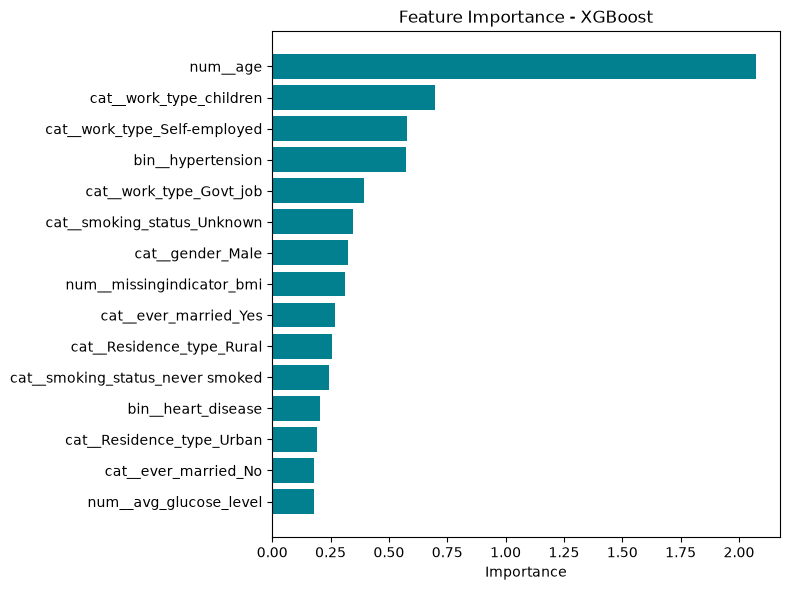

In [4]:
top15 = imp_df.head(15)
plt.figure(figsize=(8, 6))
plt.barh(top15["feature"][::-1], top15["importance"][::-1], color="#028090")
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("results/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring="average_precision", n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
1,age,0.209026,0.010603
7,avg_glucose_level,0.034501,0.010250
5,work_type,0.033217,0.020506
2,hypertension,0.016612,0.012061
8,bmi,0.012854,0.023515
3,heart_disease,0.007105,0.001703
0,gender,0.006530,0.007785
4,ever_married,0.001210,0.003801
9,smoking_status,0.000998,0.011456
6,Residence_type,-0.000218,0.002609


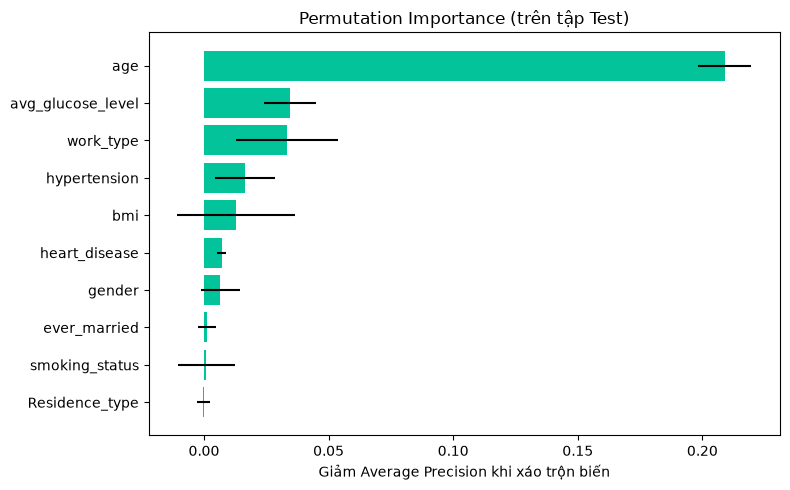

In [7]:
plt.figure(figsize=(8, 5))
plt.barh(perm_df["feature"][::-1], perm_df["importance_mean"][::-1],
         xerr=perm_df["importance_std"][::-1], color="#02C39A")
plt.title("Permutation Importance (trên tập Test)")
plt.xlabel("Giảm Average Precision khi xáo trộn biến")
plt.tight_layout()
plt.savefig("results/permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()